In [1]:
!pip install tensorflow

In [2]:
import tensorflow as tf
from tensorflow.keras import layers,models
from tensorflow import keras
import numpy as np
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

C:\Users\ANAMIKA\anaconda3\Lib\site-packages\keras\src\export\tf2onnx_lib.py:8: FutureWarning: In the future `np.object` will be defined as the corresponding NumPy scalar.
  if not hasattr(np, "object"):


In [3]:
IMAGE_SIZE = 150
BATCH_SIZE = 32
CHANNELS = 3
EPOCHS = 50

In [4]:
!pip install kagglehub

### *Load the dataset and explore its structure (number of classes, sample images, image sizes).*

In [5]:
import kagglehub
# Download latest version
path = kagglehub.dataset_download("puneet6060/intel-image-classification")

print("Path to dataset files:", path)

Path to dataset files: C:\Users\ANAMIKA\.cache\kagglehub\datasets\puneet6060\intel-image-classification\versions\2


In [6]:
import os
os.listdir(path)

['seg_pred', 'seg_test', 'seg_train']

In [7]:
data_path = os.path.join(path, "seg_pred", "seg_train", "seg_test")
data_path

'C:\\Users\\ANAMIKA\\.cache\\kagglehub\\datasets\\puneet6060\\intel-image-classification\\versions\\2\\seg_pred\\seg_train\\seg_test'

In [8]:
pred_path = os.path.join(path, "seg_pred", "seg_pred")
test_path = os.path.join(path, "seg_test", "seg_test")

In [9]:
train_path = os.path.join(path, "seg_train", "seg_train")
os.listdir(train_path)

['buildings', 'forest', 'glacier', 'mountain', 'sea', 'street']

In [10]:
train_ds = tf.keras.preprocessing.image_dataset_from_directory(
    train_path,
    shuffle=True,
    image_size=(IMAGE_SIZE, IMAGE_SIZE),
    batch_size=BATCH_SIZE
)

Found 14034 files belonging to 6 classes.


In [11]:
test_ds = tf.keras.preprocessing.image_dataset_from_directory(
    test_path,
    shuffle=False,
    image_size=(IMAGE_SIZE, IMAGE_SIZE),
    batch_size=BATCH_SIZE
)

Found 3000 files belonging to 6 classes.


In [12]:
pred_ds = tf.keras.preprocessing.image_dataset_from_directory(
    pred_path,
    labels=None, 
    shuffle=False,
    image_size=(IMAGE_SIZE, IMAGE_SIZE),
    batch_size=BATCH_SIZE
)

Found 7301 files.


In [13]:
val_ds = tf.keras.preprocessing.image_dataset_from_directory(
    test_path,           
    shuffle=True,
    image_size=(150, 150),
    batch_size=32
)


Found 3000 files belonging to 6 classes.


In [14]:
num_classes1 = len(os.listdir(train_path))
print("Number of classes:", num_classes1)

Number of classes: 6


In [15]:
num_classes2 = len(os.listdir(test_path))
print("Number of classes:", num_classes2)

Number of classes: 6


In [16]:
num_classes3 = len(os.listdir(pred_path))
print("Number of classes:", num_classes3)

Number of classes: 7301


In [17]:
from PIL import Image
import os
train_path = os.path.join(path, "seg_train", "seg_train")
sample_class = os.listdir(train_path)[0]
sample_image = os.listdir(os.path.join(train_path, sample_class))[0]
img_path = os.path.join(train_path, sample_class, sample_image)
img = Image.open(img_path)
print("Original image size:", img.size)

Original image size: (150, 150)


In [18]:
class_names = train_ds.class_names
class_names

['buildings', 'forest', 'glacier', 'mountain', 'sea', 'street']

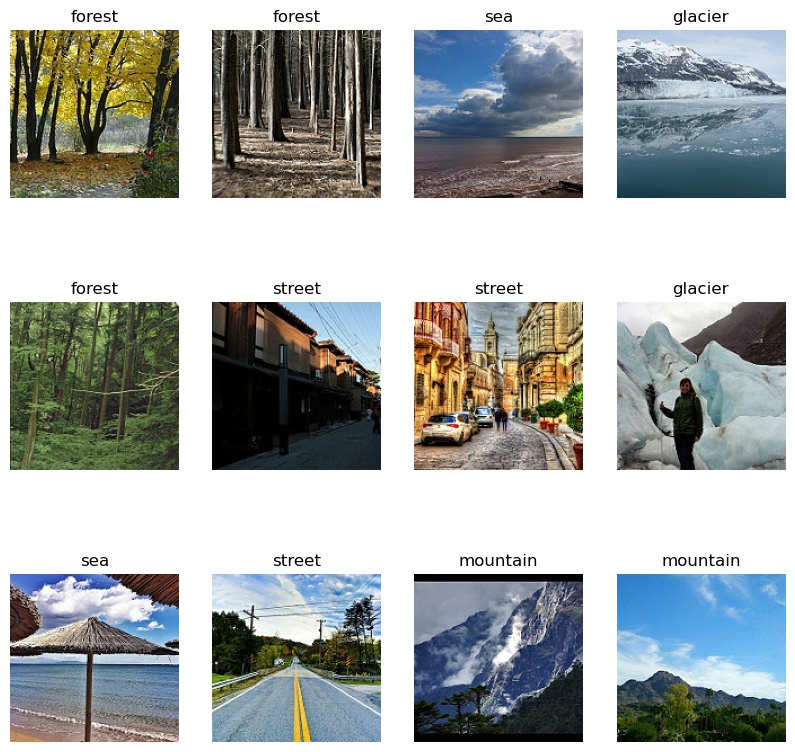

In [19]:
plt.figure(figsize=(10,10))
for image_batch, label_batch in train_ds.take(1):
  for i in range(12):
    ax = plt.subplot(3,4,i+1)
    plt.imshow(image_batch[i].numpy().astype("uint8"))
    plt.title(class_names[label_batch[i]])
    plt.axis("off")

### *Perform data preprocessing steps:*

In [20]:
IMAGE_SIZE = 150
resize_and_rescale = tf.keras.Sequential([
    tf.keras.layers.Resizing(IMAGE_SIZE, IMAGE_SIZE),
    tf.keras.layers.Rescaling(1.0 / 255)
])

In [21]:
data_augmentation = tf.keras.Sequential([
    layers.RandomFlip("horizontal_and_vertical"),
    layers.RandomRotation(0.2),
    layers.RandomZoom(0.1),
    layers.RandomTranslation(0.1, 0.1)
])

In [22]:
AUTOTUNE = tf.data.AUTOTUNE

In [23]:
train_ds = train_ds.map(lambda x, y: (data_augmentation(x, training=True), y),
                        num_parallel_calls=AUTOTUNE)

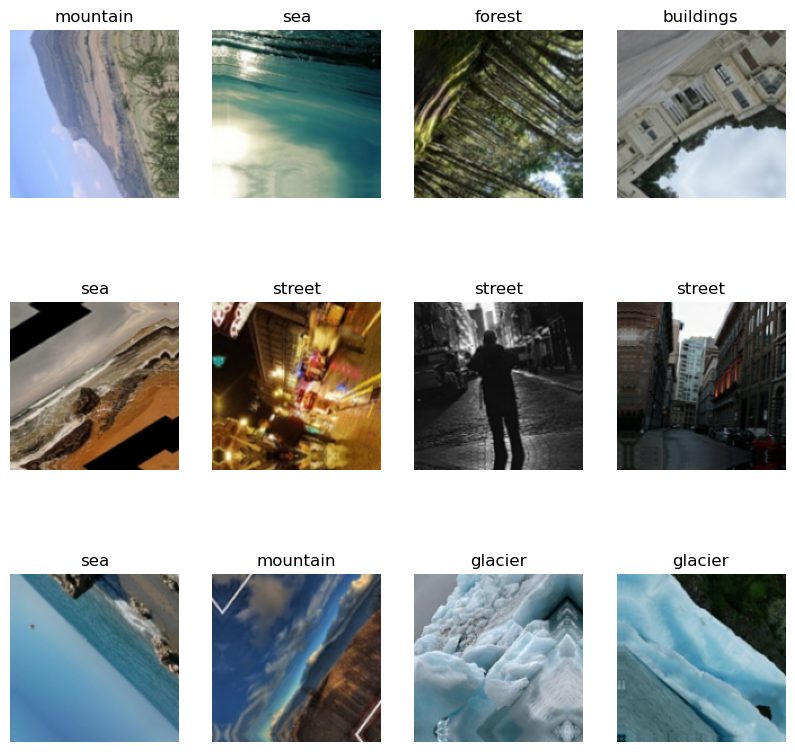

In [24]:
plt.figure(figsize=(10,10))
for image_batch, label_batch in train_ds.take(1):
  for i in range(12):
    ax = plt.subplot(3,4,i+1)
    plt.imshow(image_batch[i].numpy().astype("uint8"))
    plt.title(class_names[label_batch[i]])
    plt.axis("off")


### *Build a Convolutional Neural Network (CNN) from scratch using TensorFlow/Keras or PyTorch.*

In [25]:
input_shape = (IMAGE_SIZE, IMAGE_SIZE, CHANNELS)
n_classes = 6

model = models.Sequential([
    #resize_and_rescale,  # This layer sets the input shape implicitly
    layers.Conv2D(32, (3,3), activation='relu', input_shape=input_shape),
    layers.MaxPooling2D(2, 2),

    layers.Conv2D(64, (3,3), activation='relu'),
    layers.MaxPooling2D(2, 2),

    layers.Conv2D(64, (3,3), activation='relu'),
    layers.MaxPooling2D(2, 2),

    layers.Conv2D(64, (3,3), activation='relu'),
    layers.MaxPooling2D(2, 2),

    layers.Conv2D(64, (3,3), activation='relu'),
    layers.MaxPooling2D(2, 2),

    layers.Flatten(),
    layers.Dense(64, activation='relu'),
    layers.Dropout(0.5),
    layers.Dense(6, activation='softmax')
])

# Build with only the image shape, no batch size
model.build(input_shape=(None, IMAGE_SIZE, IMAGE_SIZE, CHANNELS))


In [26]:
model.summary()

Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 148, 148, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 74, 74, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 72, 72, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 36, 36, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 34, 34, 64)     │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 17, 17, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 15, 15, 64)     │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 7, 7, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 5, 5, 64)       │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_4 (MaxPooling2D)  │ (None, 2, 2, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 64)             │        16,448 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 6)              │           390 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 147,014 (574.27 KB)

 Trainable params: 147,014 (574.27 KB)

 Non-trainable params: 0 (0.00 B)

In [27]:
model.compile(
    optimizer='adam',
    loss=tf.keras.losses.SparseCategoricalCrossentropy(from_logits=False),
    metrics=['accuracy']
)

### *Train the CNN model on the training dataset and validate it on the validation set.*

In [28]:
from tensorflow.keras.callbacks import EarlyStopping

early_stop = EarlyStopping(
    monitor='val_loss',      
    patience=5,              
    restore_best_weights=True,  
    min_delta=0.001         
)

In [29]:
history = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=50,
    callbacks=[early_stop],
    verbose=1
)

Epoch 1/50
439/439 ━━━━━━━━━━━━━━━━━━━━ 169s 378ms/step - accuracy: 0.3557 - loss: 1.6864 - val_accuracy: 0.3960 - val_loss: 1.3785
Epoch 2/50
439/439 ━━━━━━━━━━━━━━━━━━━━ 203s 461ms/step - accuracy: 0.4321 - loss: 1.3752 - val_accuracy: 0.3170 - val_loss: 1.8764
Epoch 3/50
439/439 ━━━━━━━━━━━━━━━━━━━━ 164s 373ms/step - accuracy: 0.4662 - loss: 1.3113 - val_accuracy: 0.4920 - val_loss: 1.2924
Epoch 4/50
439/439 ━━━━━━━━━━━━━━━━━━━━ 228s 519ms/step - accuracy: 0.4941 - loss: 1.2655 - val_accuracy: 0.4447 - val_loss: 1.5243
Epoch 5/50
439/439 ━━━━━━━━━━━━━━━━━━━━ 165s 375ms/step - accuracy: 0.5185 - loss: 1.2296 - val_accuracy: 0.4683 - val_loss: 1.5158
Epoch 6/50
439/439 ━━━━━━━━━━━━━━━━━━━━ 207s 472ms/step - accuracy: 0.5324 - loss: 1.1977 - val_accuracy: 0.5993 - val_loss: 1.0726
Epoch 7/50
439/439 ━━━━━━━━━━━━━━━━━━━━ 172s 390ms/step - accuracy: 0.5493 - loss: 1.1600 - val_accuracy: 0.5223 - val_loss: 1.2549
Epoch 8/50
439/439 ━━━━━━━━━━━━━━━━━━━━ 168s 381ms/step - accuracy: 0.5698 -

In [30]:
scores = model.evaluate(test_ds)

94/94 ━━━━━━━━━━━━━━━━━━━━ 9s 91ms/step - accuracy: 0.6510 - loss: 0.9266


In [32]:
acc = history.history['accuracy']
val_acc = history.history['val_accuracy']

loss = history.history['loss']
val_loss = history.history['val_loss']

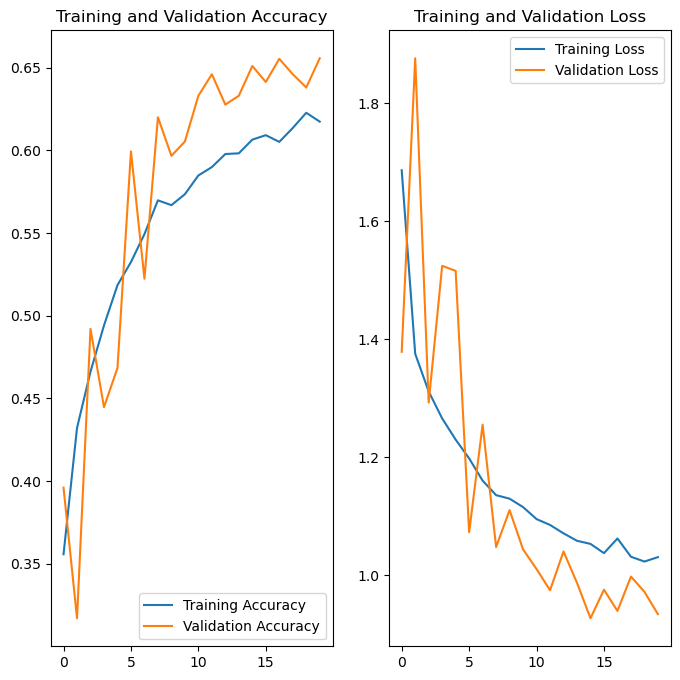

In [33]:
acc = history.history['accuracy']
val_acc = history.history['val_accuracy']
loss = history.history['loss']
val_loss = history.history['val_loss']

epochs_range = range(len(acc))   # number of epochs actually trained

plt.figure(figsize=(8, 8))

plt.subplot(1, 2, 1)
plt.plot(epochs_range, acc, label='Training Accuracy')
plt.plot(epochs_range, val_acc, label='Validation Accuracy')
plt.legend(loc='lower right')
plt.title('Training and Validation Accuracy')

plt.subplot(1, 2, 2)
plt.plot(epochs_range, loss, label='Training Loss')
plt.plot(epochs_range, val_loss, label='Validation Loss')
plt.legend(loc='upper right')
plt.title('Training and Validation Loss')

plt.show()

## *Evaluate the model on the test set and report performance metrics*

In [34]:
test_loss, test_accuracy = model.evaluate(val_ds, verbose=1)

print(f"Test Accuracy: {test_accuracy:.4f}")
print(f"Test Loss: {test_loss:.4f}")

94/94 ━━━━━━━━━━━━━━━━━━━━ 10s 100ms/step - accuracy: 0.6510 - loss: 0.9266
Test Accuracy: 0.6510
Test Loss: 0.9266


In [36]:
import numpy as np

y_true = []
y_pred = []

for images, labels in val_ds:
    predictions = model.predict(images)
    y_pred.extend(np.argmax(predictions, axis=1))
    y_true.extend(labels.numpy())

y_true = np.array(y_true)
y_pred = np.array(y_pred)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 452ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 133ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 118ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 164ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 126ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 115ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 133ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 126ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 129ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 121ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 153ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 120ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 112ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 131ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 102ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 113ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 126ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 111ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 114ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 136ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 108ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 118ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 113ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 104ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 100ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 

In [37]:
from sklearn.metrics import classification_report

class_names = val_ds.class_names

print(classification_report(
    y_true,
    y_pred,
    target_names=class_names
))

              precision    recall  f1-score   support

   buildings       0.49      0.57      0.52       437
      forest       0.82      0.95      0.88       474
     glacier       0.59      0.75      0.66       553
    mountain       0.72      0.53      0.61       525
         sea       0.71      0.43      0.54       510
      street       0.63      0.68      0.65       501

    accuracy                           0.65      3000
   macro avg       0.66      0.65      0.64      3000
weighted avg       0.66      0.65      0.64      3000



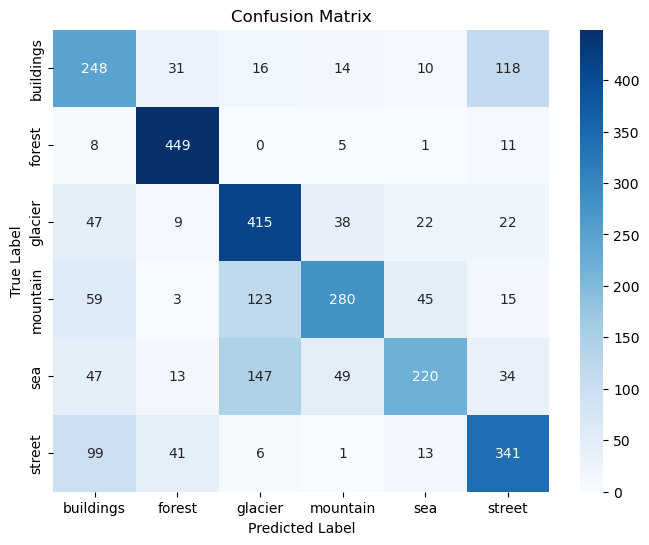

In [38]:
from sklearn.metrics import confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns

cm = confusion_matrix(y_true, y_pred)

plt.figure(figsize=(8,6))
sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues',
    xticklabels=class_names,
    yticklabels=class_names
)
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.title('Confusion Matrix')
plt.show()

## *Visualize predictions for at least 10 random test images with predicted vs. actual labels.*

In [41]:
model.save("model.h5")

In [42]:
loaded_model = tf.keras.models.load_model("model.h5")